In [1]:
import numpy as np
from plots import plot_lv, plot_vm, plot_dp, plot2, plot_lv2, plot_lv_with_control_pts
from pathlib import Path

# Define boundaries for cantilever example
vertices = np.array(
    [
        (0.0, 0.0),
        (2.0, 0.0),
        (2.0, 0.45),
        (2.0, 0.55),
        (2.0, 1.0),
        (0.0, 1.0),
        (0.0, 0.0),
    ]
)
dir_idx, dir_mkr = [6], 1
neu_idx, neu_mkr = [3], 2
dir = np.array(vertices[(dir_idx[0] - 1) : (dir_idx[-1] + 1)])
neu = np.array(vertices[(neu_idx[0] - 1) : (neu_idx[-1] + 1)])
boundaries_cantilever = [(dir, "blue"), (neu, "red")]
max_dp_cantilever = 0.3
max_vm_cantilever = 30.0
limits_cantilever = [[-0.01, 2.1], [-0.15, 1.01]] 

# Define boundaries for inverter example
a, b = 0.05, 0.05
vertices = np.array(
    [
        (0.0, 0.0),
        (1.0, 0.0),
        (1.0, 0.5 - a),
        (1.0, 0.5 + a),
        (1.0, 1.0),
        (0.0, 1.0),
        (0.0, 1.0 - b),
        (0.0, 0.5 + a),
        (0.0, 0.5 - a),
        (0.0, b),
        (0.0, 0.0)
    ]
)

dirB_idx, dirB_mkr = [10], 1
dirT_idx, dirT_mkr = [6], 2
neuL_idx, neuL_mkr = [8], 3
neuR_idx, neuR_mkr = [3], 4

dirB = np.array(vertices[(dirB_idx[0] - 1) : (dirB_idx[-1] + 1)])
dirT = np.array(vertices[(dirT_idx[0] - 1) : (dirT_idx[-1] + 1)])
neuL = np.array(vertices[(neuL_idx[0] - 1) : (neuL_idx[-1] + 1)])
neuR = np.array(vertices[(neuR_idx[0] - 1) : (neuR_idx[-1] + 1)])

boundaries_inverter = [(dirB, "blue"), (dirT, "blue"), (neuL, "red"), (neuR, "red")]
max_dp_inverter = 0.1
max_vm_inverter = 14.0
limits_inverter = [[-0.1, 1.1], [-0.1, 1.1]] 

# Define boundaries for inverter(symmetric) example
a, b = 0.05, 0.05
vertices = np.array(
    [
        (0.0, 0.5),
        (1.0, 0.5),
        (1.0, 0.5 + a),
        (1.0, 1.0),
        (0.0, 1.0),
        (0.0, 1.0 - b),
        (0.0, 0.5 + a),
        (0.0, 0.5)
    ]
)

# dir_base_idx, dir_base_mkr = [1], 1  # base
dirC_idx, dirC_mkr = [5], 2  # corner
neuL_idx, neuL_mkr = [7], 3  # left
neuR_idx, neuR_mkr = [2], 4  # right

# dir_base = np.array(vertices[(dir_base_idx[0] - 1) : (dir_base_idx[-1] + 1)])
dirC = np.array(vertices[(dirC_idx[0] - 1) : (dirC_idx[-1] + 1)])
neuL = np.array(vertices[(neuL_idx[0] - 1) : (neuL_idx[-1] + 1)])
neuR = np.array(vertices[(neuR_idx[0] - 1) : (neuR_idx[-1] + 1)])

boundaries_invsym = [(dirC, "blue"), (neuL, "red"), (neuR, "red")]
max_dp_invsym = 0.1
max_vm_invsym = 20.0
limits_invsym = [[-0.1, 1.1], [0.5, 1.1]] 

# Compliance minimization
(for Hooke, Saint Venant–Kirchhoff, and Mooney–Rivlin models)

Cost function:

$$
    J_\alpha(\Omega) = \int_\Gamma g\cdot u + \alpha \int_\mathcal{D} \chi_\Omega
$$

State equation:

$$
    u\in H :\quad
    \int_\mathcal{D} A_\Omega W'(I+\nabla u)(\nabla v) = \int_\Gamma g\cdot v
    \qquad \forall v \in H
$$

Adjoint equation:

$$
    p\in H :\quad
    \int_\mathcal{D} A_\Omega W''(I+\nabla u)(\nabla p, \nabla q) = -\int_\Gamma g\cdot q
    \qquad \forall q \in H    
$$

Shape derivative:

$$
    dJ(\Omega)(\theta) = \int_\mathcal{D} S_1\colon\! D\theta
$$

with

$$
    S_1 = A_\Omega \left( W'(I + \nabla u)(\nabla p)\,I  -\nabla u^\top \hat{Q_1} -\nabla p^\top \hat{Q_2}\right) + \alpha\chi_\Omega I
$$

where $\hat{Q_1} = \hat{Q_1}(I + \nabla u)$ and $\hat{Q_2} = \hat{Q_2}(I + \nabla u, \nabla p)$ are defined for each model.

>$\hat{Q}_1$ is the first Piola–Kirchhoff stress:
>
>$$
>    W'(F)(\delta F) = \delta F \colon\! P(F) = \delta F \colon\! \hat{Q}_1(F) 
>$$

>$\hat{Q}_2$ is the *tangent* of the first Piola–Kirchhoff stress:
>
>$$
>    W''(F)(\delta F_1, \delta F_2) = \delta F_1 \colon\! P'(F)(\delta F_2) = \delta F_1 \colon\! \hat{Q}_2(F, \delta F_2) 
>$$

**Numerical tests:**

- We use
    $$
        \boldsymbol{S}(A) = \lambda \mathrm{tr}(A)I +2 \mu A
    $$
    with $\lambda=115.385$ and $\mu=76.923$ (Young's modulus 200 and Poisson's ratio 0.3).

- For Moony–Rivlin we choose
    $$
        Z(x)=\beta x^2 - \gamma \ln(x),
    $$
    see Ciarlet, Section 4.10.

- $\lambda$ and $\mu$ are the basis for obtaining $a_1$, $a_2$, $\beta$, $\gamma$; see
    [Müller, B., 2015. Mixed least squares finite element methods based on inverse stress-strain relations in hyperelasticity. Bericht / Universität Duisburg-Essen, Institut für Mechanik](https://duepublico2.uni-due.de/receive/duepublico_mods_00038480), Sections 2.4.3-5, p. 48.

- We choose $g=(0, -10)$ and Lagrange multiplier $\alpha=0.25$.

- Stepping Newton method was applied in Saint–Venant–K. and Moony–Rivlin, with $8$ and $16$ times (by iteration of level set method), respectively.

- We choose $a_2 = 0.56$ (there is a range of values for $a_2$). For larger values, the stepping Newton method fails to converge. A improved stepping method is necessary; equally spaced iterations (fixed number of iterations) is not enough.

- Number of triangles = 46356

- Von Mises stress
    $$
        \left(\frac{3}{2} B\sigma\colon\!\sigma\right)^{1/2}
    $$
    with $B\sigma=\sigma-\frac{1}{3}\mathrm{tr}(\sigma)I$ 


**Displacement and Von Mises stress projection:**

Since the Displacement and Von Mises stress are defined on the domain $\mathcal{D}$, in order to show them only on $\Omega$ we make the following smooth $L^2$-projection:

Given $f$ (displacement or Von Mises stress) defined on $\mathcal{D}$,
find $v^\text{proj}\in H^1(\mathcal{D})$ such that

$$
    \int_{\mathcal{D}} v^\text{proj}w + h^2 \nabla v^\text{proj} \nabla w =
    \int_{\mathcal{D}} \chi_\Omega f w
    \qquad \forall w\in H^1(\mathcal{D})
$$

where $h\approx$ the mean of the triangle diameters.

## Hooke model

The energy is given by 

$$
    W(F) = \frac{1}{2}\boldsymbol{S}\left(\mathrm{sym}(F)-I\right)\colon\!\left(\mathrm{sym}(F)-I\right)
$$

The  Piola–Kirchhoff components are

$$
    \hat{Q}_1(F) = \boldsymbol{S}(\mathrm{sym}(F) - I),
    \qquad
    \hat{Q}_2(F,\delta F) = \boldsymbol{S}(\mathrm{sym}(\delta F)) 
$$

>The Cauchy stress given by
>$$
>    \sigma = \hat{Q}_1(F) = \boldsymbol{S}(\mathrm{sym}(\nabla u))
>$$
>

> Displacement (in norm) - maximum value =  0.26819902126536693
> Von Mises stress - maximum value =  24.35069940376637


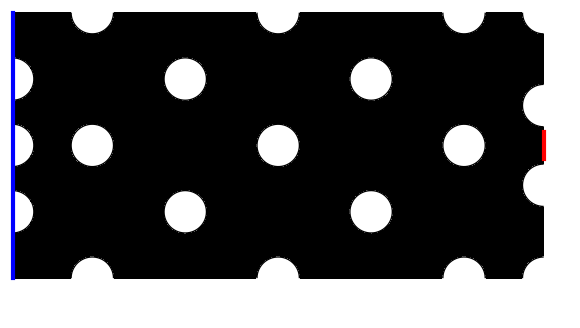

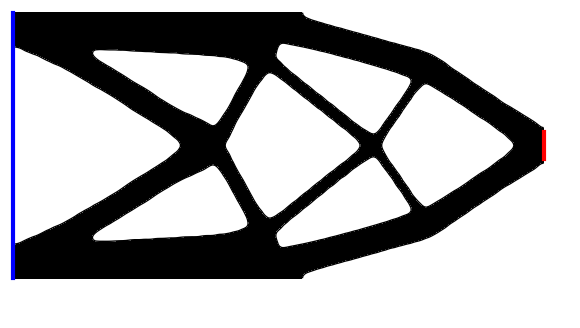

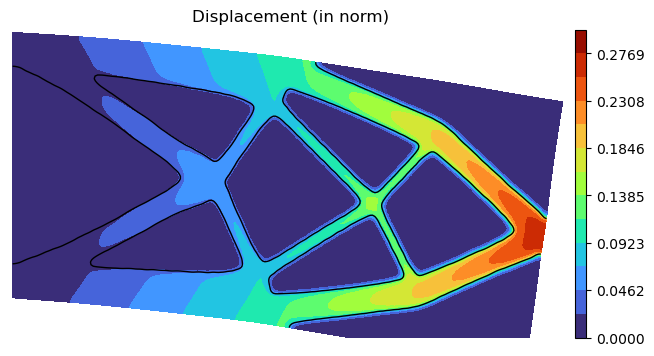

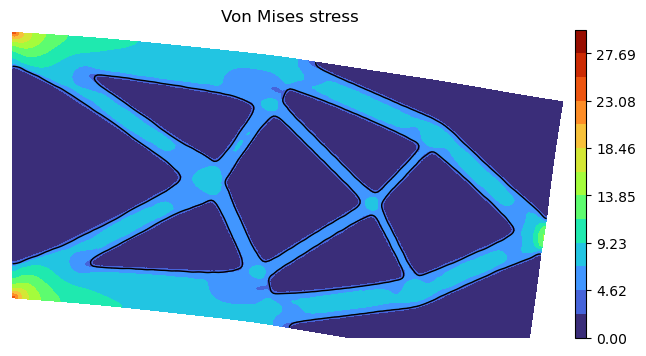

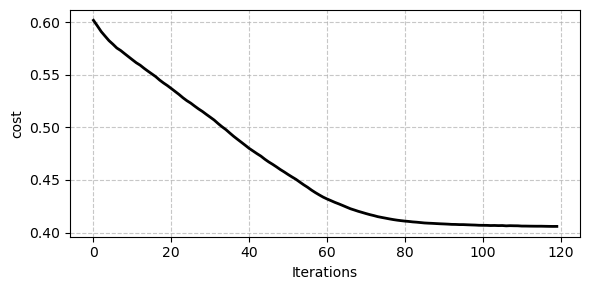

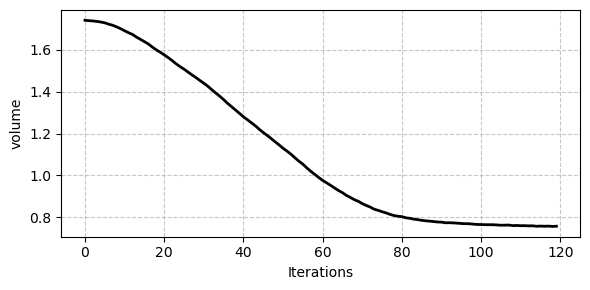

In [2]:
test_path = Path("../results/Elasticity/t01/")
cost_values = np.load(test_path / "data.npz")["cost"]
volume_values = np.load(test_path / "data.npz")["Volume"]
niter = cost_values.shape[0] - 1

plot_lv(test_path, 0, limits_cantilever, displacement=False, figsize=(8, 4), boundaries=boundaries_cantilever, lw=3)
plot_lv(test_path, niter, limits_cantilever, displacement=False, figsize=(8, 4), boundaries=boundaries_cantilever, lw=3)
plot_dp(test_path, niter, limits_cantilever, max_dp_cantilever, figsize=(8, 4))
plot_vm(test_path, niter, limits_cantilever, max_vm_cantilever, figsize=(8, 4))
plot2(cost_values, "cost", (6, 3))
plot2(volume_values, "volume", (6, 3))

## Saint-Venant-Kirchhoff model

The energy is given by

$$
    W(F) = \frac{1}{2}\boldsymbol{S}\left(\frac{F^\top F - I}{2}\right) \colon\!\left(\frac{F^\top F - I}{2}\right)
$$

and the Piola components are

$$
    \hat{Q}_1 (F) = F\,\boldsymbol{S}\left(\frac{F^\top F - I}{2}\right),
$$
$$
    \hat{Q}_2(F,\delta F) =
    \delta F\, \boldsymbol{S}\left(\frac{F^\top F - I}{2}\right) +
    F\, \boldsymbol{S}(\mathrm{sym}(F^\top \delta F))
$$

>The Cauchy stress given by
>$$
>    \sigma = \frac{1}{\det F}\hat{Q}_1 (F) F^\top
>$$
>

115
> Displacement (in norm) - maximum value =  0.26608955060933737
> Von Mises stress - maximum value =  28.86454760141607


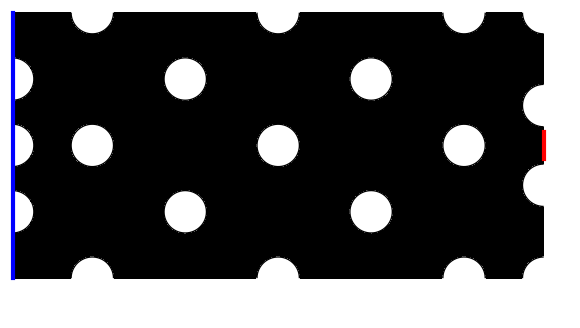

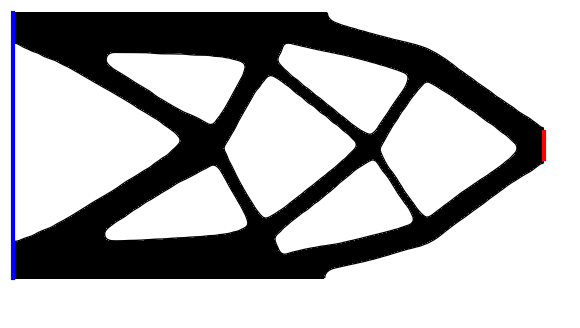

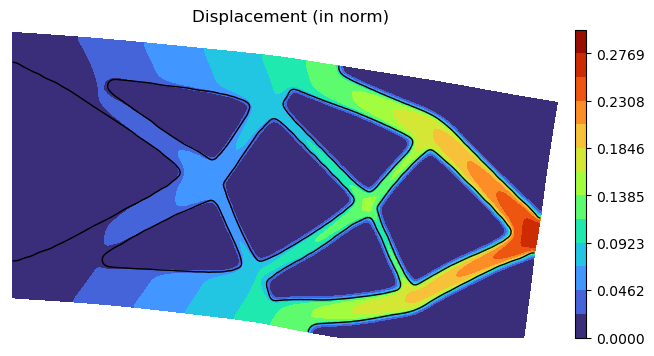

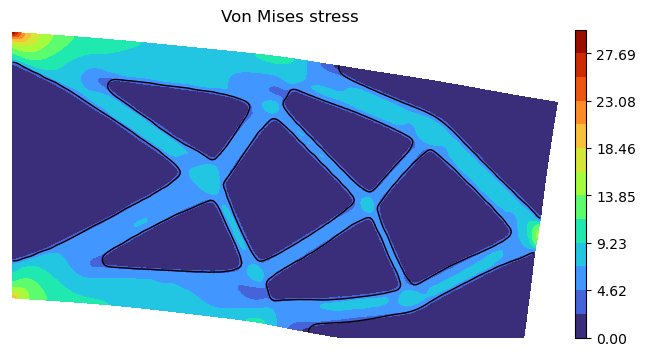

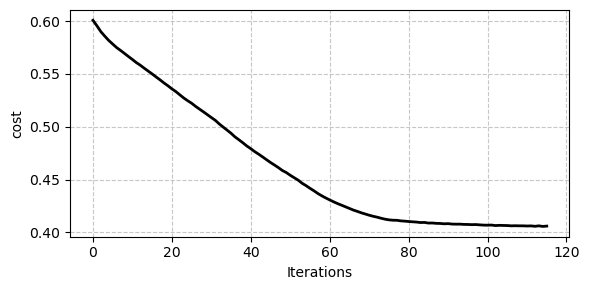

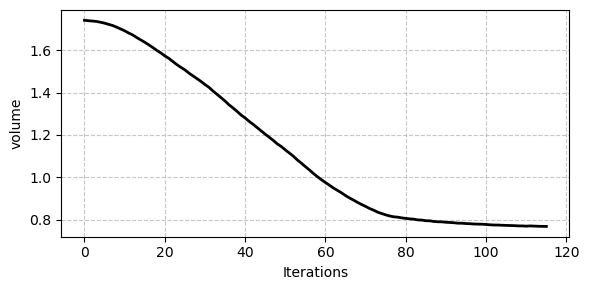

In [3]:
test_path = Path("../results/t102/")
cost_values = np.load(test_path / "data.npz")["cost"]
volume_values = np.load(test_path / "data.npz")["Volume"]
niter = cost_values.shape[0] - 1
print(niter)

plot_lv(test_path, 0, limits_cantilever, displacement=False, figsize=(8, 4), boundaries=boundaries_cantilever, lw=3)
plot_lv(test_path, niter, limits_cantilever, displacement=False, figsize=(8, 4), boundaries=boundaries_cantilever, lw=3)
plot_dp(test_path, niter, limits_cantilever, max_dp_cantilever, figsize=(8, 4))
plot_vm(test_path, niter, limits_cantilever, max_vm_cantilever, figsize=(8, 4))
plot2(cost_values, "cost", (6, 3))
plot2(volume_values, "volume", (6, 3))

## Mooney-Rivlin model

Set $H=\mathrm{Cof}(F)$ and $J=\det(F)$. The energy is given by

$$
    W(F) = \frac{a_1}{2}F\colon\!F + \frac{a_2}{2}H\colon\!H +Z(J)
$$

$Z(x)=$ `beta*x**2 - gamma*ln(x)`, with Piola components
$$
    \hat{Q}_1(F) = a_1 F + a_2 M(F; H) + Z'(J) H,
$$

$$
    \hat{Q}_2(F,\delta F) =
    a_1\delta F +
    a_2 M(F; \mathrm{Cof}'(F)(\delta F)) +
    a_2 M'(F;H)(\delta F) +
    Z'(J)M(F;\delta F) +
    Z''(J)(H\colon\!\delta F)H
$$

- $M(A;B)$ has different expressions for 2D and 3D

- $M'(A;B)(\delta A) = 0$ in 2D and $M'(A;B)(\delta A) = M(\delta A; B)$ in 3D

- $\mathrm{Cof}(F)$ is different in 2D and 3D; in both cases the Cayley-Hamilton theorem provides expressions without $F^{-1}$ 💡

- $\mathrm{Cof}'(F)(\delta F)\colon\!B = \delta F\colon\!M(F;B)$

- $\mathrm{Cof}''(F)(\delta F_1, \delta F_2)\colon\!B = \delta F_1\colon\!M'(F;B)(\delta F_2)$

>The Cauchy stress given by
>$$
>    \sigma = \frac{1}{\det F}\hat{Q}_1 (F) F^\top
>$$
>

130
> Displacement (in norm) - maximum value =  0.2663718540209846
> Von Mises stress - maximum value =  24.051517956634957


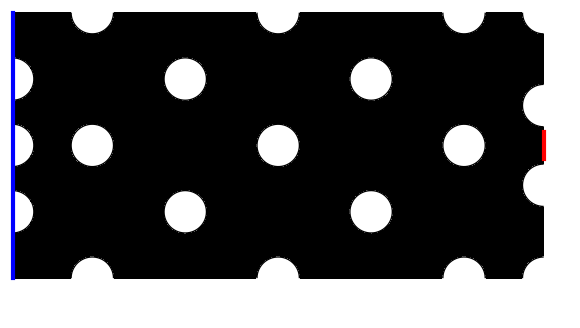

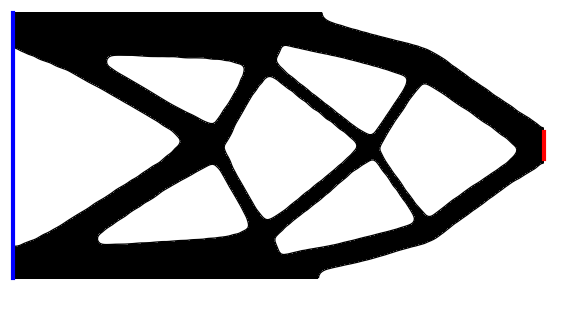

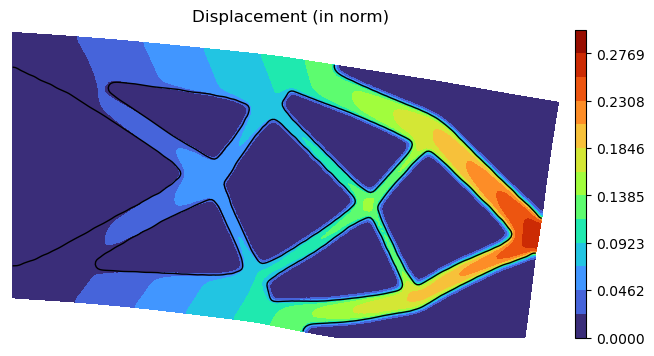

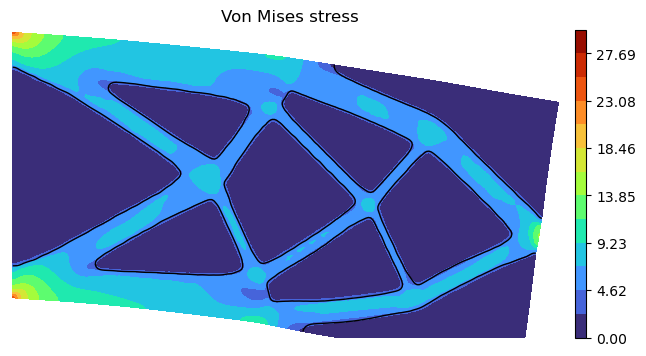

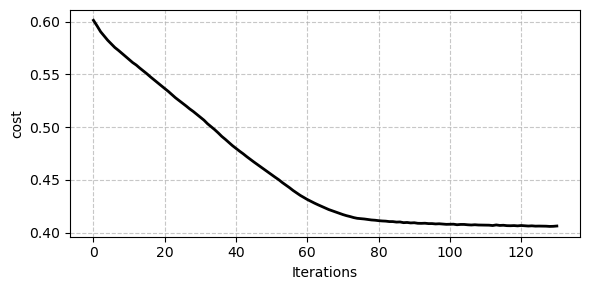

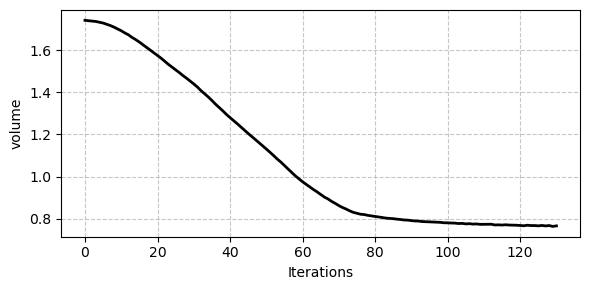

In [4]:
test_path = Path("../results/t103/")
cost_values = np.load(test_path / "data.npz")["cost"]
volume_values = np.load(test_path / "data.npz")["Volume"]
niter = cost_values.shape[0] - 1
print(niter)

plot_lv(test_path, 0, limits_cantilever, displacement=False, figsize=(8, 4), boundaries=boundaries_cantilever, lw=3)
plot_lv(test_path, niter, limits_cantilever, displacement=False, figsize=(8, 4), boundaries=boundaries_cantilever, lw=3)
plot_dp(test_path, niter, limits_cantilever, max_dp_cantilever, figsize=(8, 4))
plot_vm(test_path, niter, limits_cantilever, max_vm_cantilever, figsize=(8, 4))
plot2(cost_values, "cost", (6, 3))
plot2(volume_values, "volume", (6, 3))

## Summary

### Stress

> Von Mises stress - maximum value =  24.35069940376637
> Von Mises stress - maximum value =  28.86454760141607
> Von Mises stress - maximum value =  24.051517956634957


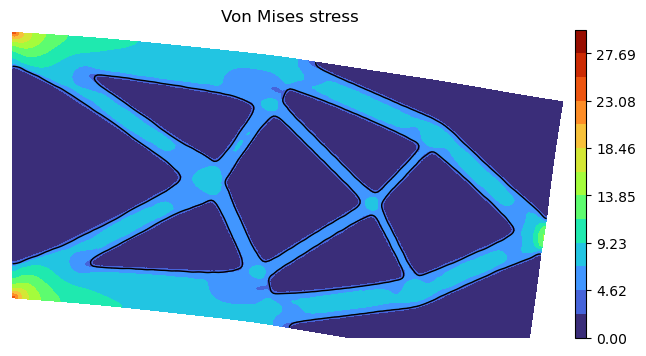

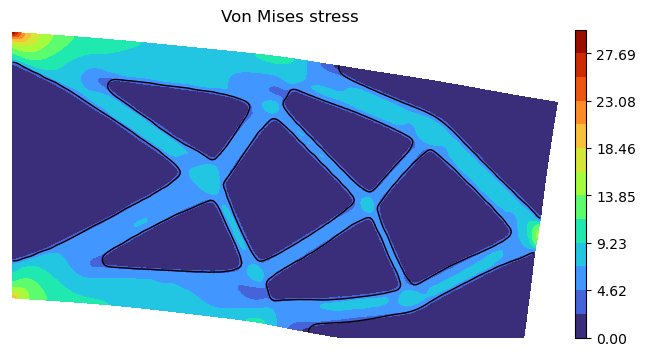

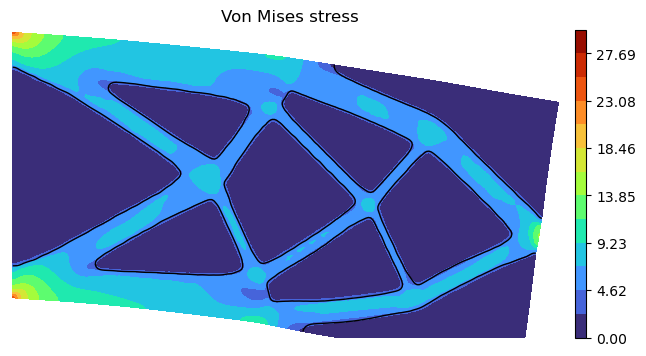

In [5]:
for test_path in [Path("../results/t101/"), Path("../results/t102/"), Path("../results/t103/")]:
    cost_values = np.load(test_path / "data.npz")["cost"]
    niter = cost_values.shape[0] - 1
    plot_vm(test_path, niter, limits_cantilever, max_vm_cantilever, figsize=(8, 4))

### Deformations

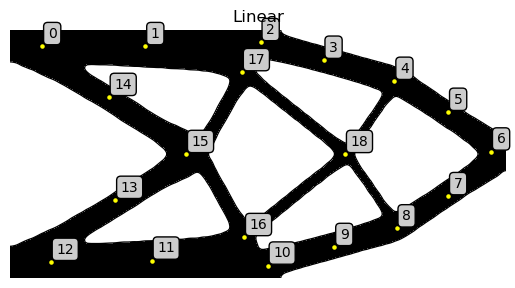

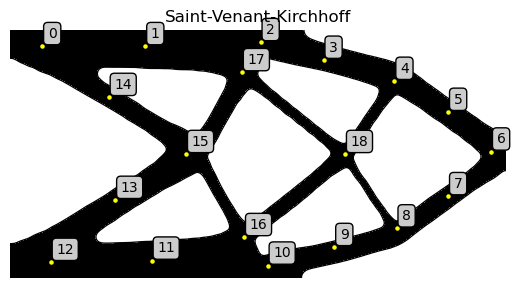

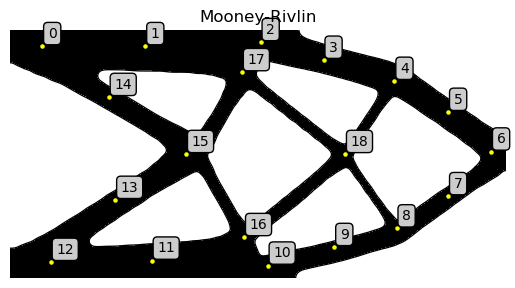

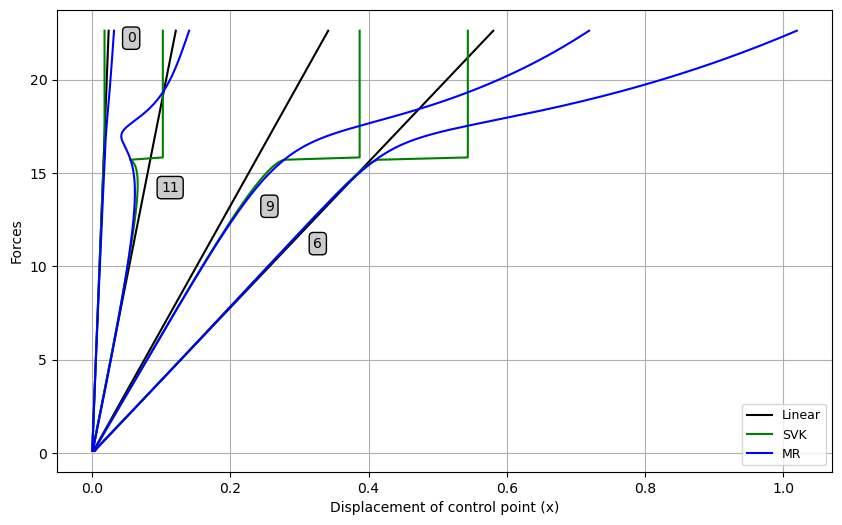

In [6]:

idxs = [
    2972,
    7671,
    13144,
    15843,
    19079,
    21230,
    22610,
    20159,
    17371,
    14254,
    10909,
    5490,
    846,
    4454,
    5346,
    8328,
    10114,
    11869,
    15824
]

test_path = Path("../results/t101/")
cost_values = np.load(test_path / "data.npz")["cost"]
norms1 = plot_lv_with_control_pts(test_path, 180, [[0.0, 2.0], [0.0, 1.0]], idxs, title="Linear")
test_path = Path("../results/t102/")
cost_values = np.load(test_path / "data.npz")["cost"]
norms2 = plot_lv_with_control_pts(test_path, 180, [[0.0, 2.0], [0.0, 1.0]], idxs, title="Saint-Venant-Kirchhoff")
test_path = Path("../results/t103/")
cost_values = np.load(test_path / "data.npz")["cost"]
norms3 = plot_lv_with_control_pts(test_path, 180, [[0.0, 2.0], [0.0, 1.0]], idxs, title="Mooney-Rivlin")

control_points = [0,6,9,11]
factors = np.linspace(0, 1.0, 200)[1:]
forces = factors[:180]*25.0

import matplotlib.pyplot as plt


groups = [norms1[control_points], norms2[control_points], norms3[control_points]]
colors = ['black', 'green', 'blue']
labels = ["Linear", "SVK", "MR"]
markers = ['o', 's', '^', 'd']

fig, ax = plt.subplots(figsize=(10, 6))

for g_idx, group in enumerate(groups):
    color = colors[g_idx]
    for f_idx, row in enumerate(group):
        #ax.plot(row, forces, marker=markers[f_idx], color=color, markevery=10, label=labels[g_idx] + "-" + str(control_points[f_idx]))
        ax.plot(row, forces, color=color, label=labels[g_idx])

ax.annotate('0', (0.05, 22), bbox =dict(boxstyle="round", fc="0.8"))
ax.annotate('11', (0.1, 14), bbox =dict(boxstyle="round", fc="0.8"))
ax.annotate('9', (0.25, 13), bbox =dict(boxstyle="round", fc="0.8"))
ax.annotate('6', (0.32, 11), bbox =dict(boxstyle="round", fc="0.8"))

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=9)

ax.set_xlabel('Displacement of control point (x)')
ax.set_ylabel('Forces')
ax.grid(True)

plt.show()


In [9]:
factors = np.linspace(0, 1.0, 200)[1:]
print(factors[142]*25.0)

17.964824120603016


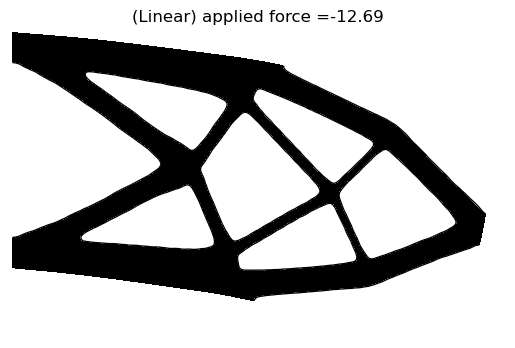

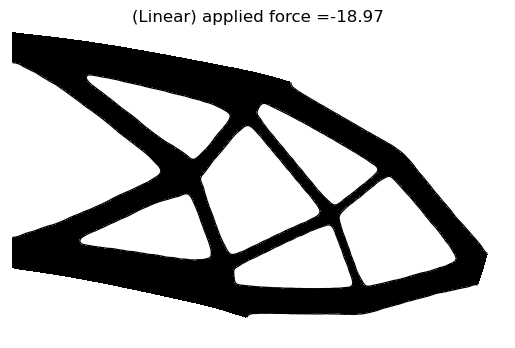

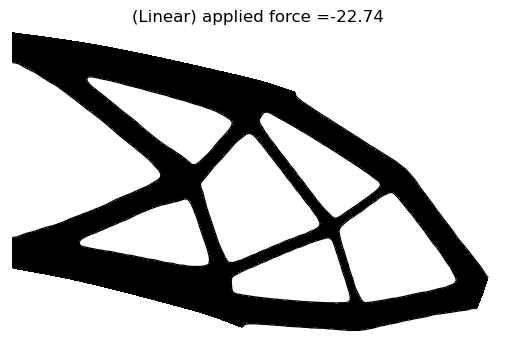

In [5]:
test_path = Path("../results/t101/")
factors = np.linspace(0, 1.0, 200)[1:]
for i in [100, 150, 180]:
    plot_lv2(test_path, f"{i:03}", [[-0.01, 2.1], [-0.3, 1.01]], title= f"(Linear) applied force ={np.round(-factors[i]*25.0, 2)}")

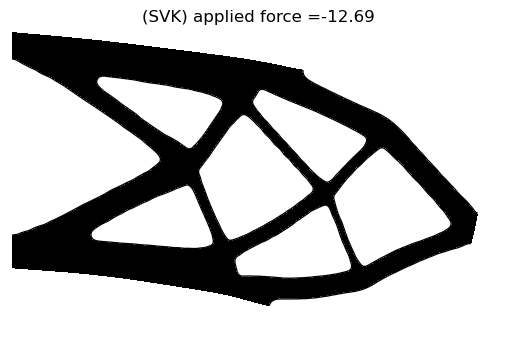

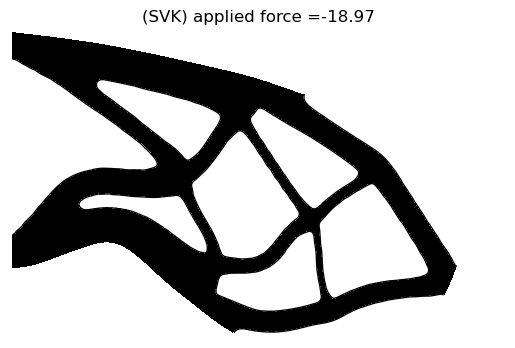

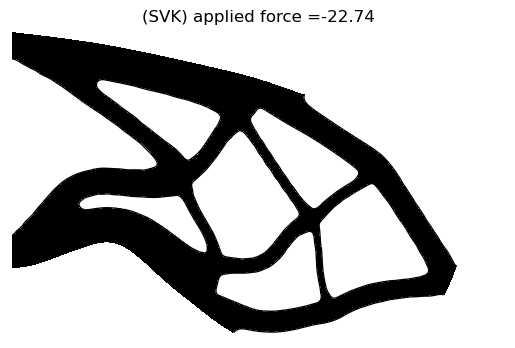

In [8]:
test_path = Path("../results/t102/")
factors = np.linspace(0, 1.0, 200)[1:]
for i in [100, 150, 180]:
    plot_lv2(test_path, f"{i:03}", [[-0.01, 2.1], [-0.3, 1.01]], title= f"(SVK) applied force ={np.round(-factors[i]*25.0, 2)}")

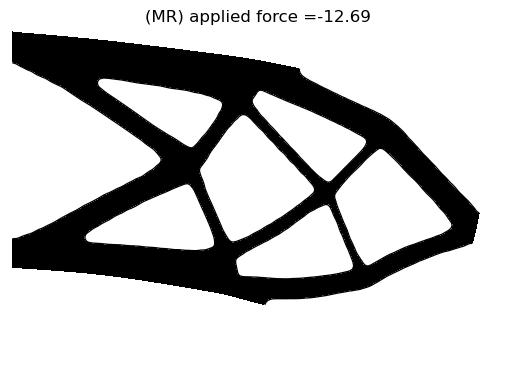

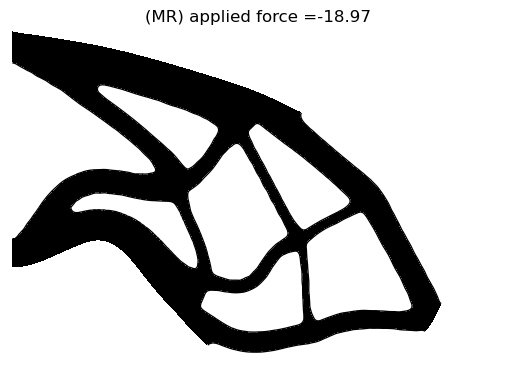

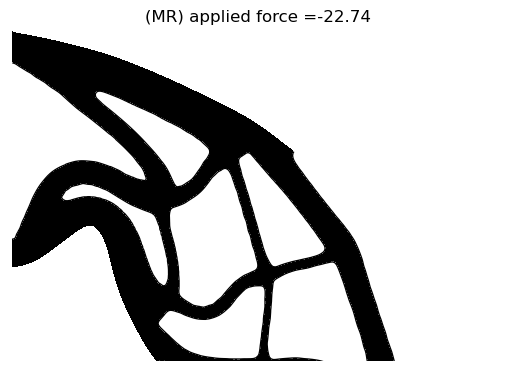

In [9]:
test_path = Path("../results/t103/")
factors = np.linspace(0, 1.0, 200)[1:]
for i in [100, 150, 180]:
    plot_lv2(test_path, f"{i:03}", [[-0.01, 2.1], [-0.4, 1.01]], title= f"(MR) applied force ={np.round(-factors[i]*25.0, 2)}")

## Comparation of shapes and displacements

### Hooke model (linear)

Applied force =-18.0


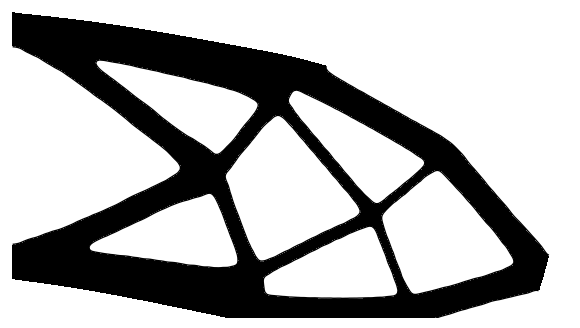

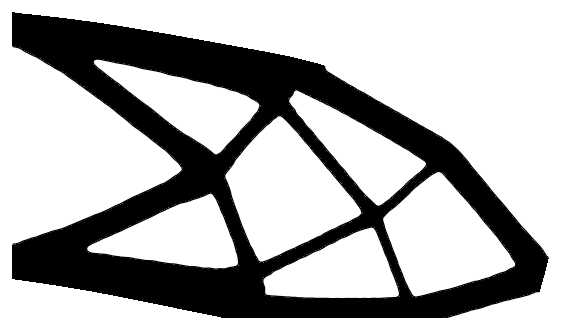

In [21]:
test_path = Path("../results/t101/")
factors = np.linspace(0, 1.0, 200)[1:]
i=142
plot_lv2(test_path, f"{i:03}", limits_cantilever, figsize=(8, 4))

test_path = Path("../results/Elasticity/t04")
cost_values = np.load(test_path / "data.npz")["cost"]
volume_values = np.load(test_path / "data.npz")["Volume"]
niter = cost_values.shape[0] - 1
plot_lv(test_path, niter, limits_cantilever, displacement=True, figsize=(8, 4), lw=3)

print(f"Applied force ={np.round(-factors[i]*25.0, 1)}")

### Saint-Venant-Kirchhoff

Applied force =-18.0


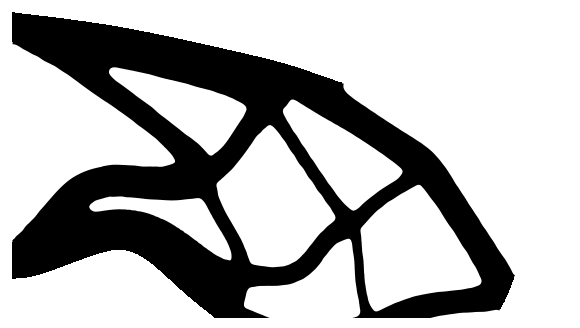

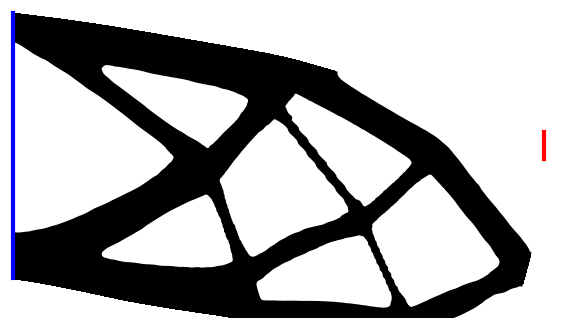

In [2]:
test_path = Path("../results/t102/")
factors = np.linspace(0, 1.0, 200)[1:]
i=142
plot_lv2(test_path, f"{i:03}", limits_cantilever, figsize=(8, 4))

test_path = Path("../results/Elasticity/t05")
cost_values = np.load(test_path / "data.npz")["cost"]
volume_values = np.load(test_path / "data.npz")["Volume"]
niter = cost_values.shape[0] - 1
plot_lv(test_path, niter, limits_cantilever, displacement=True, figsize=(8, 4), boundaries=boundaries_cantilever, lw=3)

print(f"Applied force ={np.round(-factors[i]*25.0, 1)}")

### Mooney-Rivlin model

In [ ]:
test_path = Path("../results/t103/")
factors = np.linspace(0, 1.0, 200)[1:]
i=142
plot_lv2(test_path, f"{i:03}", limits_cantilever, figsize=(8, 4))

test_path = Path("../results/Elasticity/t06")
cost_values = np.load(test_path / "data.npz")["cost"]
volume_values = np.load(test_path / "data.npz")["Volume"]
niter = cost_values.shape[0] - 1
plot_lv(test_path, niter, limits_cantilever, displacement=True, figsize=(8, 4), boundaries=boundaries_cantilever, lw=3)

print(f"Applied force ={np.round(-factors[i]*25.0, 1)}")

# Mechanism

Cost function:

$$
    J_\alpha(\Omega) = \int_{\Gamma_\text{in}} g_{\text{in}}\cdot u + \kappa\int_{\Gamma_\text{out}} g_{\text{out}}\cdot u + \alpha \int_\mathcal{D} \chi_\Omega
$$

State equation:

$$
    u\in H :\quad
    \int_\mathcal{D} A_\Omega W'(I+\nabla u)(\nabla v) = \int_{\Gamma_\text{in}} g_{\text{in}}\cdot v + \int_{\Gamma_\text{out}} g_{\text{out}}\cdot v
    \qquad \forall v \in H
$$

Adjoint equation:

$$
    p\in H :\quad
    \int_\mathcal{D} A_\Omega W''(I+\nabla u)(\nabla p, \nabla q) = -\int_{\Gamma_\text{in}} g_{\text{in}}\cdot q - \kappa\int_{\Gamma_\text{out}} g_{\text{out}}\cdot q
    \qquad \forall q \in H    
$$

> Displacement (in norm) - maximum value =  0.0917946721919799
> Von Mises stress - maximum value =  14.14220156367089


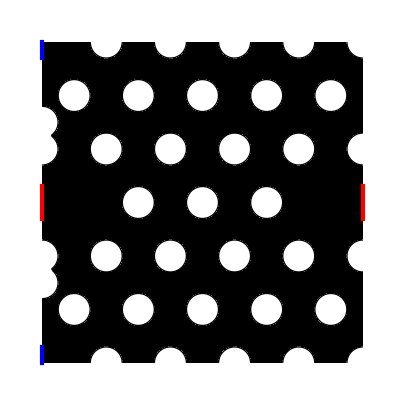

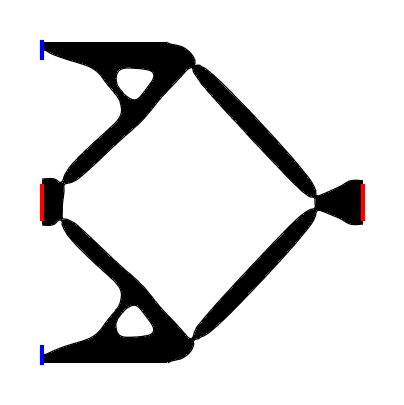

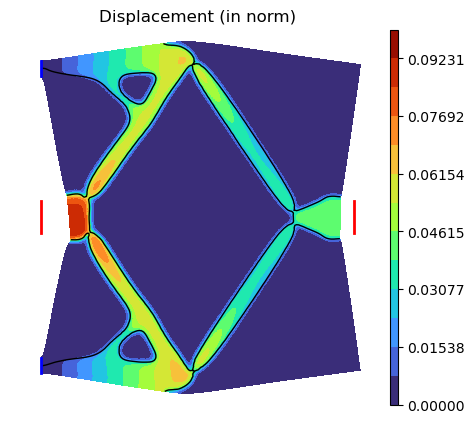

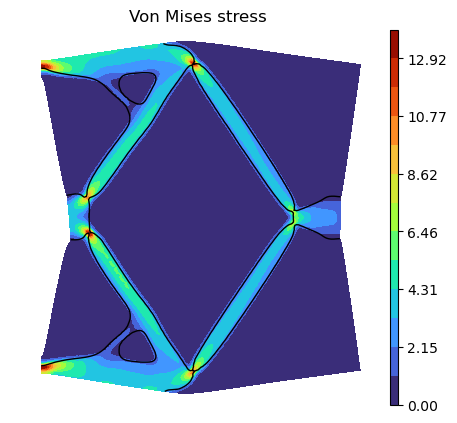

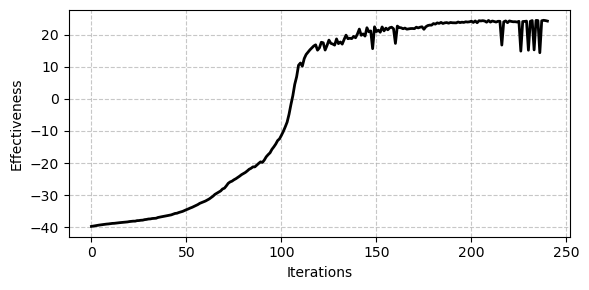

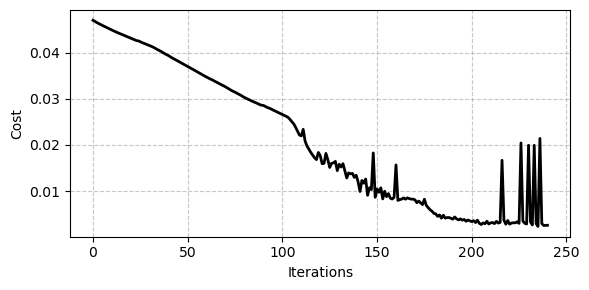

In [10]:
test_path = Path("../results/t201/")
data = np.load(test_path / "data.npz")
cost_values = data["cost"]
volume_values = data["Volume"]
InDisp = data["InDisp"]
OutDisp = data["OutDisp"]
ee = -100.0*OutDisp/InDisp
niter = 240#cost_values.shape[0] - 1

plot_lv(test_path, 0, limits_inverter, displacement=False, figsize=(5, 5), boundaries=boundaries_inverter, lw=3)
plot_lv(test_path, niter, limits_inverter, displacement=False, figsize=(5, 5), boundaries=boundaries_inverter, lw=3)
plot_dp(test_path, niter, limits_inverter, max_dp_inverter, figsize=(5, 5),boundaries=boundaries_inverter)
plot_vm(test_path, niter, limits_inverter, max_vm_inverter, figsize=(5, 5))
plot2(ee[:(niter+1)], "Effectiveness", (6, 3))
plot2(cost_values[:(niter+1)], "Cost", (6, 3))

> Displacement (in norm) - maximum value =  0.08187139400092422
> Von Mises stress - maximum value =  13.641823136808313


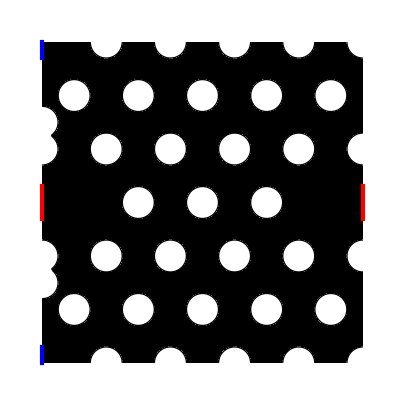

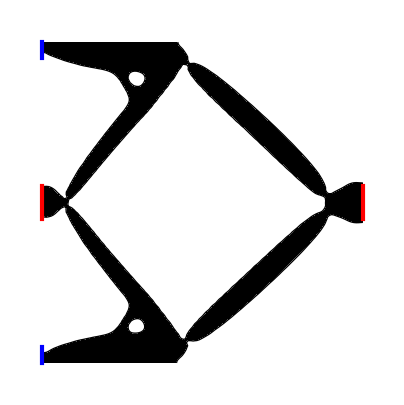

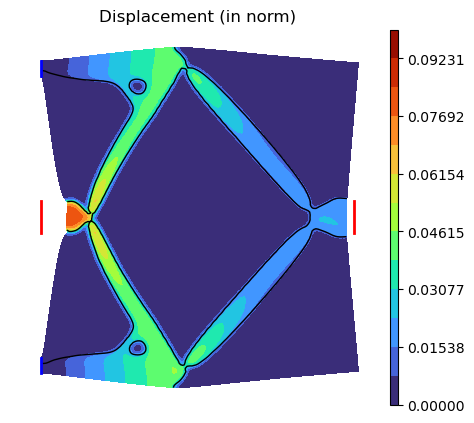

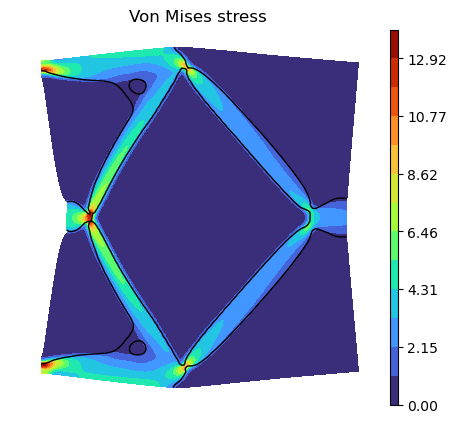

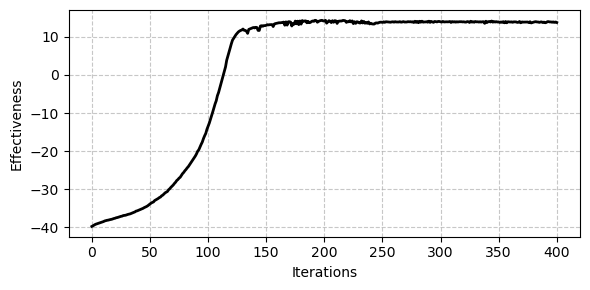

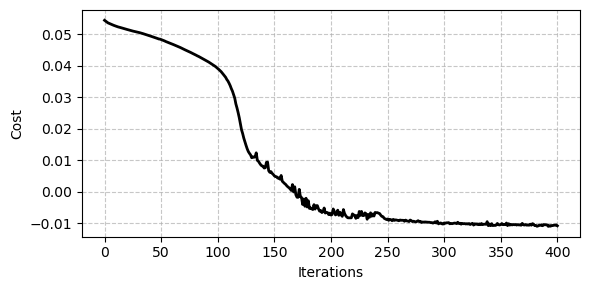

In [11]:
test_path = Path("../results/t202/")
data = np.load(test_path / "data.npz")
cost_values = data["cost"]
volume_values = data["Volume"]
InDisp = data["InDisp"]
OutDisp = data["OutDisp"]
ee = -100.0*OutDisp/InDisp
niter = cost_values.shape[0] - 1

plot_lv(test_path, 0, limits_inverter, displacement=False, figsize=(5, 5), boundaries=boundaries_inverter, lw=3)
plot_lv(test_path, niter, limits_inverter, displacement=False, figsize=(5, 5), boundaries=boundaries_inverter, lw=3)
plot_dp(test_path, niter, limits_inverter, max_dp_inverter, figsize=(5, 5),boundaries=boundaries_inverter)
plot_vm(test_path, niter, limits_inverter, max_vm_inverter, figsize=(5, 5))
plot2(ee[:(niter+1)], "Effectiveness", (6, 3))
plot2(cost_values[:(niter+1)], "Cost", (6, 3))

> Displacement (in norm) - maximum value =  0.17240622134432648
> Von Mises stress - maximum value =  5.340262757653346


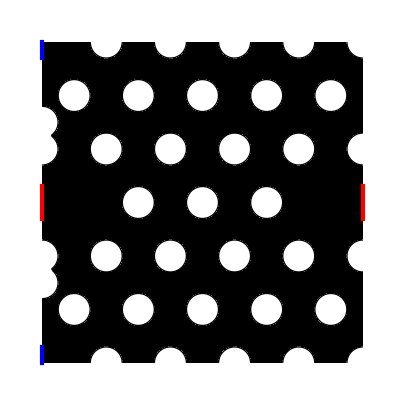

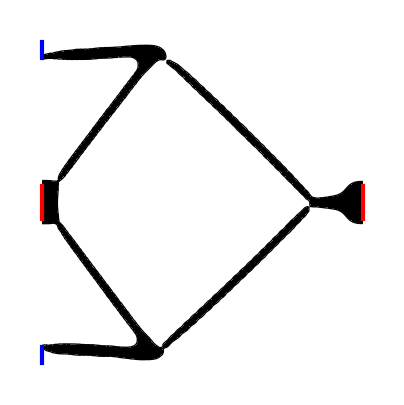

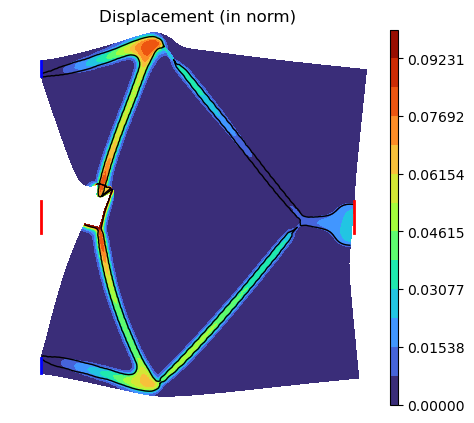

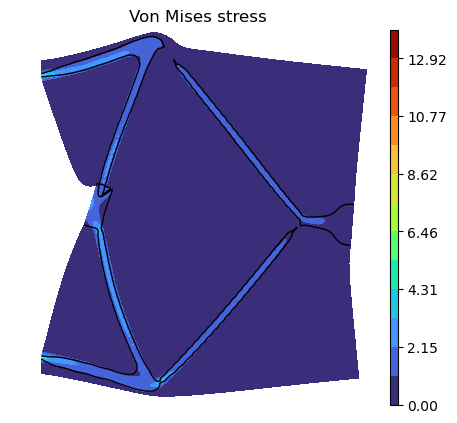

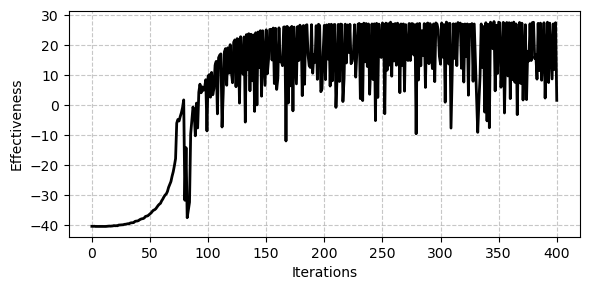

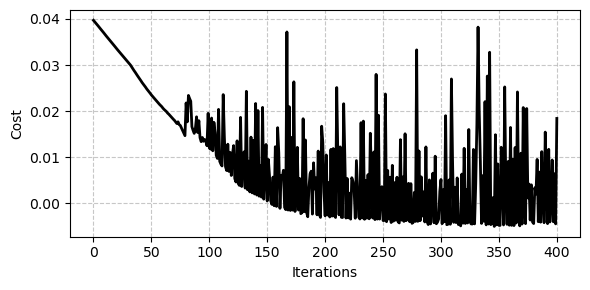

In [12]:
test_path = Path("../results/t203/")
data = np.load(test_path / "data.npz")
cost_values = data["cost"]
volume_values = data["Volume"]
InDisp = data["InDisp"]
OutDisp = data["OutDisp"]
ee = -100.0*OutDisp/InDisp
niter = cost_values.shape[0] - 1

plot_lv(test_path, 0, limits_inverter, displacement=False, figsize=(5, 5), boundaries=boundaries_inverter, lw=3)
plot_lv(test_path, niter, limits_inverter, displacement=False, figsize=(5, 5), boundaries=boundaries_inverter, lw=3)
plot_dp(test_path, niter, limits_inverter, max_dp_inverter, figsize=(5, 5),boundaries=boundaries_inverter)
plot_vm(test_path, niter, limits_inverter, max_vm_inverter, figsize=(5, 5))
plot2(ee[:(niter+1)], "Effectiveness", (6, 3))
plot2(cost_values[:(niter+1)], "Cost", (6, 3))

> Displacement (in norm) - maximum value =  0.08466846465609545
> Von Mises stress - maximum value =  14.047221604980338


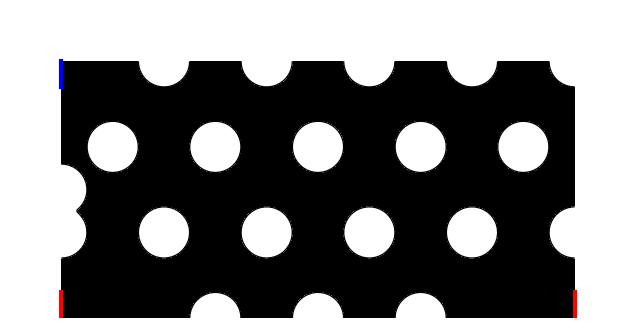

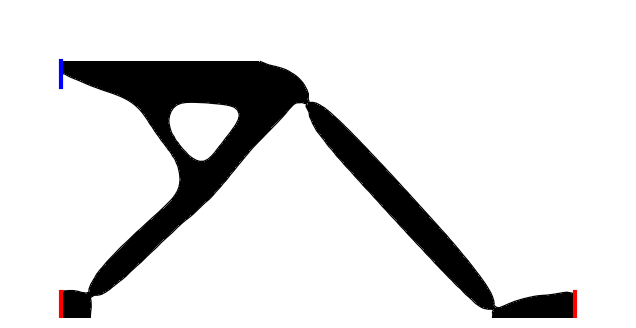

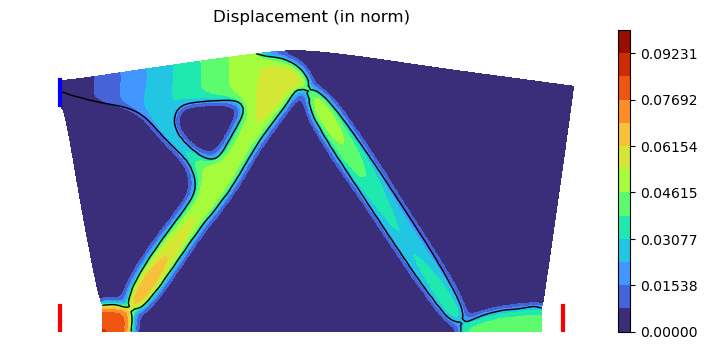

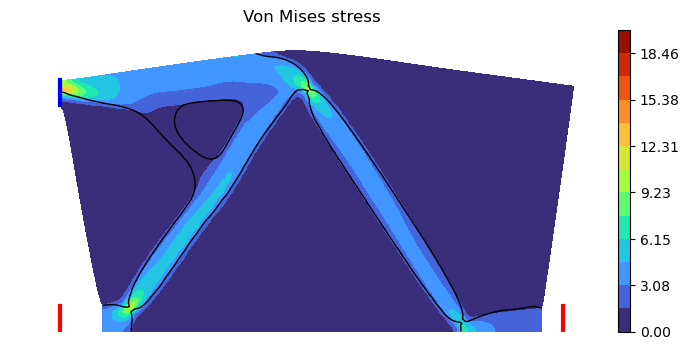

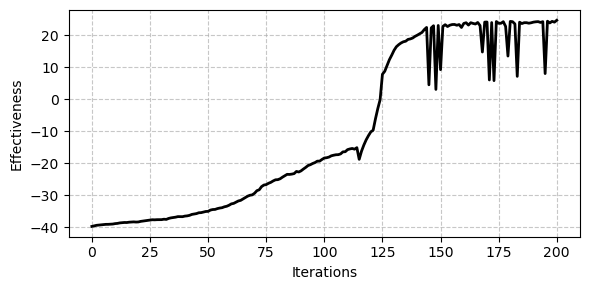

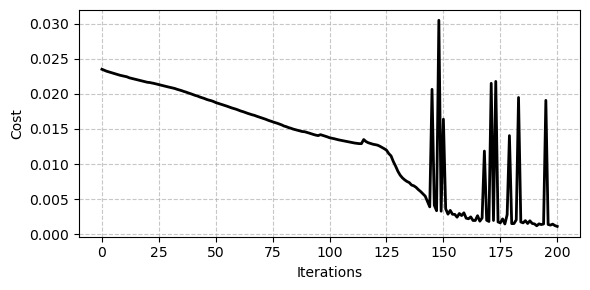

In [13]:
test_path = Path("../results/t105/")
data = np.load(test_path / "data.npz")
cost_values = data["cost"]
volume_values = data["Volume"]
InDisp = data["InDisp"]
OutDisp = data["OutDisp"]
ee = -100.0*OutDisp/InDisp
niter = 200#cost_values.shape[0] - 1

plot_lv(test_path, 0, limits_invsym, displacement=False, figsize=(8, 4), boundaries=boundaries_invsym, lw=3)
plot_lv(test_path, niter, limits_invsym, displacement=False, figsize=(8, 4), boundaries=boundaries_invsym, lw=3)
plot_dp(test_path, niter, limits_invsym, max_dp_invsym, figsize=(8, 4), boundaries=boundaries_invsym, lw=3)
plot_vm(test_path, niter, limits_invsym, max_vm_invsym, figsize=(8, 4), boundaries=boundaries_invsym, lw=3)
plot2(ee[:(niter+1)], "Effectiveness", (6, 3))
plot2(cost_values[:(niter+1)], "Cost", (6, 3))

# Mechanism (with Robin boundary conditions)

Cost function:

$$
    J_\alpha(\Omega) = \int_{\Gamma_\text{in}} g_{\text{in}}\cdot u + \int_{\Gamma_\text{out}} g_{\text{out}}\cdot u + \alpha \int_\mathcal{D} \chi_\Omega
$$

State equation:

$$
    u\in H :\quad
    \int_\mathcal{D} A_\Omega W'(I+\nabla u)(\nabla v)+
    \kappa \int_{\Gamma_\text{out}}  u\cdot v =
    \int_{\Gamma_\text{in}} g_{\text{in}}\cdot v 
    \qquad \forall v \in H
$$

Adjoint equation:

$$
    p\in H :\quad
    \int_\mathcal{D} A_\Omega W''(I+\nabla u)(\nabla p, \nabla q) +
    \kappa \int_{\Gamma_\text{out}}  p\cdot q =
    -\int_{\Gamma_\text{in}} g_{\text{in}}\cdot q - \int_{\Gamma_\text{out}} g_{\text{out}}\cdot q
    \qquad \forall q \in H    
$$

Shape derivative:

$$
    dJ(\Omega)(\theta) = \int_\mathcal{D} S_1\colon\! D\theta
$$

with

$$
    S_1 = A_\Omega \left( W'(I + \nabla u)(\nabla p)\,I  -\nabla u^\top \hat{Q_1} -\nabla p^\top \hat{Q_2}\right) + \alpha\chi_\Omega I
$$

where $\hat{Q_1} = \hat{Q_1}(I + \nabla u)$ and $\hat{Q_2} = \hat{Q_2}(I + \nabla u, \nabla p)$ are defined for each model.

> Displacement (in norm) - maximum value =  0.1662733021572047
> Von Mises stress - maximum value =  3.863690179841239


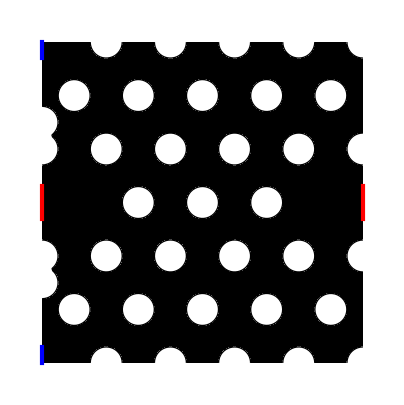

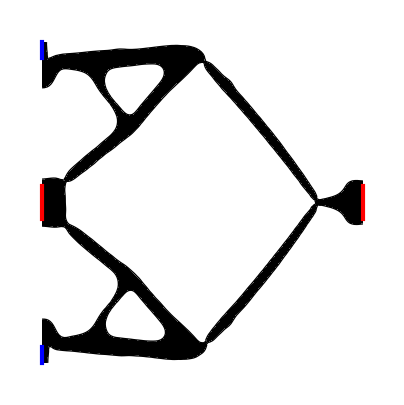

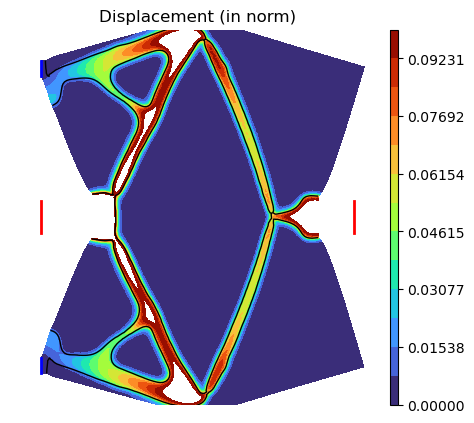

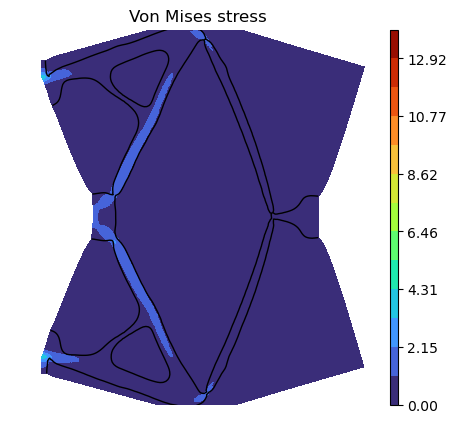

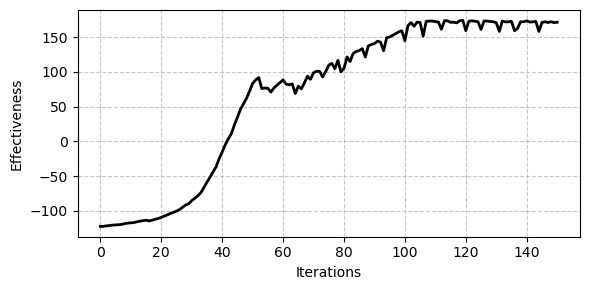

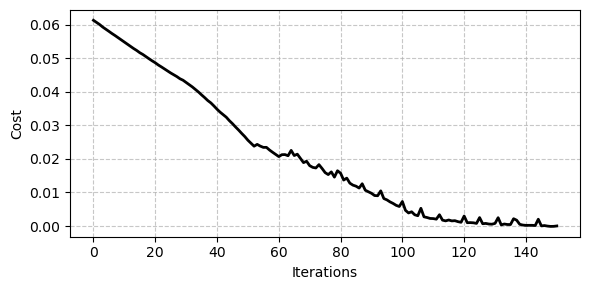

In [14]:
test_path = Path("../results/t205/")
data = np.load(test_path / "data.npz")
cost_values = data["cost"]
volume_values = data["Volume"]
InDisp = data["InDisp"]
OutDisp = data["OutDisp"]
ee = -100.0*OutDisp/InDisp
niter = cost_values.shape[0] - 1

plot_lv(test_path, 0, limits_inverter, displacement=False, figsize=(5, 5), boundaries=boundaries_inverter, lw=3)
plot_lv(test_path, niter, limits_inverter, displacement=False, figsize=(5, 5), boundaries=boundaries_inverter, lw=3)
plot_dp(test_path, niter, limits_inverter, max_dp_inverter, figsize=(5, 5),boundaries=boundaries_inverter)
plot_vm(test_path, niter, limits_inverter, max_vm_inverter, figsize=(5, 5))
plot2(ee[:(niter+1)], "Effectiveness", (6, 3))
plot2(cost_values[:(niter+1)], "Cost", (6, 3))

# Kohn–Vogelius formulation

Cost function:

$$
    J_\alpha(\Omega) = \int_{\mathcal{D}} A_{\Omega} W'(I + \nabla (u-v))(\nabla (u-v))
    + \alpha \int_\mathcal{D} \chi_\Omega
$$

State equations:

$$
    u\in H :\quad
    \int_\mathcal{D} A_\Omega W'(I+\nabla u)(\nabla w) =
    \int_{\Gamma_1} g_{1}\cdot w 
    \qquad \forall w \in H
$$

$$
    v\in H :\quad
    \int_\mathcal{D} A_\Omega W'(I+\nabla v)(\nabla w) =
    \int_{\Gamma_2} g_{2}\cdot w 
    \qquad \forall w \in H
$$

Adjoint equations:

$$
    p\in H :\quad
    \int_\mathcal{D} A_\Omega W''(I+\nabla u)(\nabla p, \nabla r) =
    -\int_\mathcal{D} A_\Omega \Phi(r)
    \qquad \forall r \in H    
$$

$$
    q\in H :\quad
    \int_\mathcal{D} A_\Omega W''(I+\nabla v)(\nabla q, \nabla r) =
    \int_\mathcal{D} A_\Omega \Phi(r)
    \qquad \forall r \in H    
$$
where
$$
\Phi(r) = W'(I+\nabla (u-v))(\nabla r) + W''(I+\nabla (u-v))(\nabla (u-v), \nabla r)
$$

Shape derivative:

$$
    dJ(\Omega)(\theta) = \int_\mathcal{D} S_1\colon\! D\theta
$$

with

$$
    S_1 = A_\Omega \left(
        W'(I + \nabla (u-v))(\nabla (u-v))
        + W'(I + \nabla u)(\nabla p) 
        + W'(I + \nabla v)(\nabla q) 
        \right)I + ...
$$


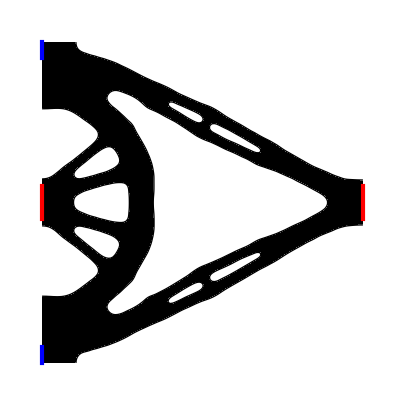

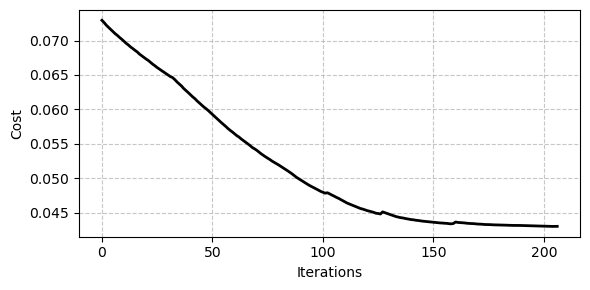

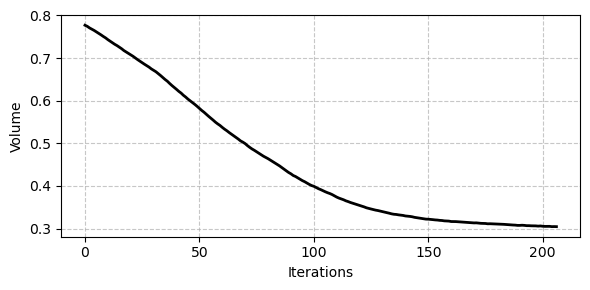

In [7]:
# Linear model, forces : (6.0, 0.0), (0.0, -6.0)
test_path = Path("../results/Elasticity/t41/")
data = np.load(test_path / "data.npz")
cost_values = data["cost"]
volume_values = data["Volume"]
niter = cost_values.shape[0] - 1

plot_lv(test_path, niter, limits_inverter, displacement=False, figsize=(5, 5), boundaries=boundaries_inverter, lw=3)
plot2(cost_values[:(niter+1)], "Cost", (6, 3))
plot2(volume_values[:(niter+1)], "Volume", (6, 3))

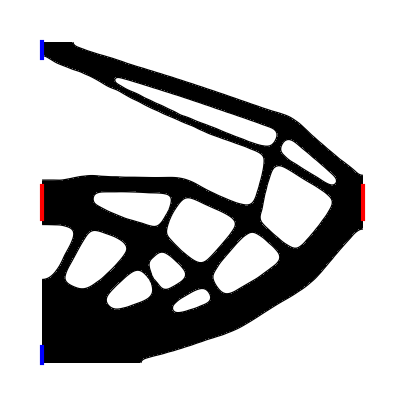

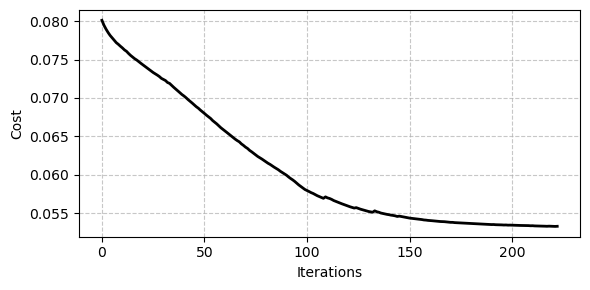

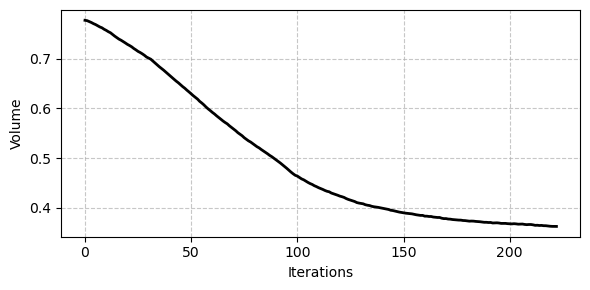

In [5]:
# Linear model, forces : (6.0, 0.0), (-6.0, 0)
test_path = Path("../results/Elasticity/t42/")
data = np.load(test_path / "data.npz")
cost_values = data["cost"]
volume_values = data["Volume"]
niter = cost_values.shape[0] - 1

plot_lv(test_path, niter, limits_inverter, displacement=False, figsize=(5, 5), boundaries=boundaries_inverter, lw=3)
plot2(cost_values[:(niter+1)], "Cost", (6, 3))
plot2(volume_values[:(niter+1)], "Volume", (6, 3))

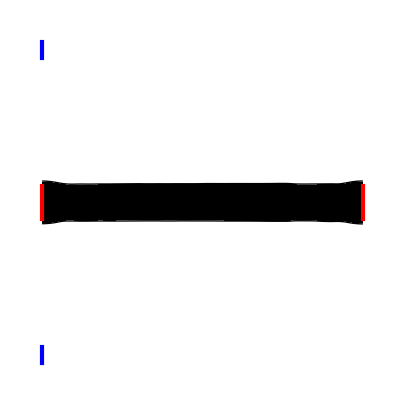

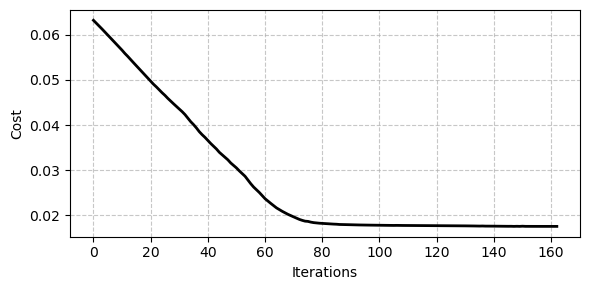

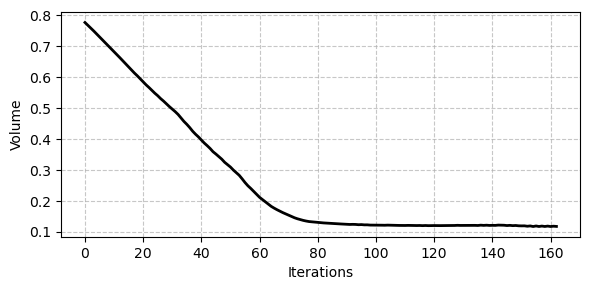

In [6]:
# Linear model, forces : (6.0, 0.0), (0.0, 6.0)
test_path = Path("../results/Elasticity/t43/")
data = np.load(test_path / "data.npz")
cost_values = data["cost"]
volume_values = data["Volume"]
niter = cost_values.shape[0] - 1

plot_lv(test_path, niter, limits_inverter, displacement=False, figsize=(5, 5), boundaries=boundaries_inverter, lw=3)
plot2(cost_values[:(niter+1)], "Cost", (6, 3))
plot2(volume_values[:(niter+1)], "Volume", (6, 3))

In [16]:
# # Define geometry and boundaries for gripping example
# vertices = np.array(
#     [
#         (0.0, 0.0),
#         (0.9, 0.0),
#         (1.0, 0.0),
#         (1.0, 0.48),
#         (1.0, 0.52),
#         (1.0, 1.0),
#         (0.9, 1.0),
#         (0.0, 1.0),
#         (0.0, 0.6),
#         (0.1, 0.6),
#         (0.1, 0.52),
#         (0.1, 0.48),
#         (0.1, 0.4),
#         (0.0, 0.4),
#     ]
# )

# dirR_idx, dirR_mkr = [4], 1
# dirL_idx, dirL_mkr = [11], 2
# neuRT_idx, neuRT_mkr = [6], 3
# neuRB_idx, neuRB_mkr = [2], 4
# neuLT_idx, neuLT_mkr = [9], 5
# neuLB_idx, neuLB_mkr = [13], 6    

# boundary_parts = [
# (dirR_idx, dirR_mkr, "dir_right"),
# (dirL_idx, dirL_mkr, "dir_left"),
# (neuRT_idx, neuRT_mkr, "neu_right_top"),
# (neuRB_idx, neuRB_mkr, "neu_right_bottom"),
# (neuLT_idx, neuLT_mkr, "neu_left_top"),
# (neuLB_idx, neuLB_mkr, "neu_left_bottom"),
# ]


# dir_idx, dir_mkr = [6], 1
# neu_idx, neu_mkr = [3], 2

# dirR = np.array(vertices[(dirR_idx[0] - 1) : (dirR_idx[-1] + 1)])
# dirL = np.array(vertices[(dirL_idx[0] - 1) : (dirL_idx[-1] + 1)])
# neuRT = np.array(vertices[(neuRT_idx[0] - 1) : (neuRT_idx[-1] + 1)])
# neuRB = np.array(vertices[(neuRB_idx[0] - 1) : (neuRB_idx[-1] + 1)])
# neuLT = np.array(vertices[(neuLT_idx[0] - 1) : (neuLT_idx[-1] + 1)])
# neuLB = np.array(vertices[(neuLB_idx[0] - 1) : (neuLB_idx[-1] + 1)])

# boundaries = [(dirR, "red"), (dirL, "red"), (neuRT, "blue"), (neuRB, "blue"), (neuLT, "blue"), (neuLB, "blue")]